In [1]:
from pynwb import NWBHDF5IO
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001568\sub-817335\sub-817335_ses-ecephys-817335-2025-08-27-14-46-51_ecephys.nwb"

In [3]:
def get_unit_probe(unit_idx, units):
    """Get the probe/device name for a unit."""
    return str(units['device_name'][unit_idx])


def select_condition(unit_idx, units, probe, all_units=False):
    """
    Determine if a unit meets selection criteria.
    
    Parameters:
    -----------
    unit_idx : int
        Index of the unit
    units : DataFrame
        Units table from NWB file
    probe : str
        Target probe name
    all_units : bool
        If True, include all units regardless of SNR
    
    Returns:
    --------
    bool : Whether the unit meets selection criteria
    """
    if all_units:
        return get_unit_probe(unit_idx, units) == probe
    
    return (units["snr"][unit_idx] > 1 and 
            get_unit_probe(unit_idx, units) == probe)


def get_rf(spike_times, xs, ys, rf_stim_table):
    """
    Calculate receptive field from spike times and stimulus presentations.
    
    Parameters:
    -----------
    spike_times : array
        Spike times for the unit
    xs : array
        X positions of RF stimuli
    ys : array
        Y positions of RF stimuli
    rf_stim_table : DataFrame
        Receptive field stimulus presentation table
    
    Returns:
    --------
    ndarray : 2D receptive field response matrix
    """
    unit_rf = np.zeros([ys.size, xs.size])
    
    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):
            # Get stimulus times for this coordinate
            stim_times = rf_stim_table[
                (rf_stim_table.x_position == str(x)) & 
                (rf_stim_table.y_position == str(y))
            ].start_time
            
            response_spike_count = 0
            for stim_time in stim_times:
                # Count spikes within 0.2 seconds after stimulus
                start_idx, end_idx = np.searchsorted(
                    spike_times, 
                    [stim_time, stim_time + 0.2]
                )
                response_spike_count += end_idx - start_idx
            
            unit_rf[yi, xi] = response_spike_count
    
    return unit_rf

In [4]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian_2d(coords, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """2D Gaussian function"""
    x, y = coords
    xo = float(xo)
    yo = float(yo)    
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp( - (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo) + c*((y-yo)**2)))
    return g.ravel()


def fit_gaussian_to_rf(rf):
    
    # Create coordinate arrays
    x = np.arange(rf.shape[1])
    y = np.arange(rf.shape[0])
    x, y = np.meshgrid(x, y)
    
    # Find the actual maximum location as a better initial guess
    max_idx = np.unravel_index(np.argmax(rf), rf.shape)
    
    # Initial guess for parameters
    amplitude_guess = rf.max() - rf.min()
    xo_guess = max_idx[1]  # Column index (x)
    yo_guess = max_idx[0]  # Row index (y)
    sigma_guess = min(rf.shape) / 4
    
    initial_guess = (amplitude_guess, xo_guess, yo_guess, sigma_guess, sigma_guess, 0, rf.min())
    
    # Set bounds to keep the center within the RF array (with some margin)
    bounds = (
        [0, -1, -1, 0.5, 0.5, -np.pi, -np.inf],  # Lower bounds (allow slight overhang)
        [np.inf, rf.shape[1], rf.shape[0], rf.shape[1]*3, rf.shape[0]*3, np.pi, np.inf]  # Upper bounds
    )
    
    try:
        # Fit the Gaussian with bounds
        popt, pcov = curve_fit(
            gaussian_2d, 
            (x, y), 
            rf.ravel(), 
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )
        
        # Calculate fitted RF
        fitted_rf = gaussian_2d((x, y), *popt).reshape(rf.shape)
        
        # Calculate R-squared
        ss_res = np.sum((rf.ravel() - fitted_rf.ravel())**2)
        ss_tot = np.sum((rf.ravel() - np.mean(rf.ravel()))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
        
        # Only reject if the fit is extremely poor or center is way out of bounds
        if r_squared < -0.5:  # Very negative R² indicates terrible fit
            print(f"Warning: R² = {r_squared:.3f} is extremely low, rejecting fit")
            return None, 0.0, None
            
        # Check if center is completely outside the reasonable range
        if popt[1] < -2 or popt[1] > rf.shape[1] + 2 or popt[2] < -2 or popt[2] > rf.shape[0] + 2:
            print(f"Warning: Fitted center ({popt[1]:.2f}, {popt[2]:.2f}) is far outside RF bounds")
            return None, 0.0, None
        
        return popt, r_squared, pcov, fitted_rf
        
    except RuntimeError as e:
        # If optimization fails, try without bounds
        print(f"Bounded fit failed, trying unbounded fit: {e}")
        try:
            popt, pcov = curve_fit(
                gaussian_2d, 
                (x, y), 
                rf.ravel(), 
                p0=initial_guess,
                maxfev=10000
            )
            
            # Calculate fitted RF
            fitted_rf = gaussian_2d((x, y), *popt).reshape(rf.shape)
            
            # Calculate R-squared
            ss_res = np.sum((rf.ravel() - fitted_rf.ravel())**2)
            ss_tot = np.sum((rf.ravel() - np.mean(rf.ravel()))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
            
            return popt, r_squared, pcov, fitted_rf
            
        except Exception as e2:
            print(f"Unbounded fit also failed: {e2}")
            return None, 0.0, None, None
            
    except Exception as e:
        print(f"Fitting failed: {e}")
        return None, 0.0, None, None

In [5]:
io = NWBHDF5IO(str(nwb_path), 'r', load_namespaces=True)
nwb = io.read()

units = nwb.units
rf_stim_table = nwb.intervals['receptive_field_block_presentations'].to_dataframe()
dg_stim_table = nwb.intervals['drifting_gratings_field_block_presentations'].to_dataframe()

# nwb_data = {
#     'nwb': nwb,
#     'units': units, 
#     'rf_stim_table': rf_stim_table,
#     'dg_stim_table': dg_stim_table
# }

probes_to_analyze = sorted(set(units['device_name'][:]))

print(probes_to_analyze)

['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']


In [6]:
probe = probes_to_analyze[0]

# Get unique RF positions
xs = list(set(rf_stim_table.x_position))
ys = list(set(rf_stim_table.y_position))

xs = [float(x) for x in xs]
ys = [float(y) for y in ys]

xs = np.sort(xs)
ys = np.sort(ys)

# Find units matching criteria
unit_indices = []
unit_rfs = []

for unit_idx in range(len(units)):
    if select_condition(unit_idx, units, probe):
        unit_indices.append(unit_idx)
        
        # Get spike times and calculate RF
        spike_times = nwb.units['spike_times'][unit_idx]
        unit_rf = get_rf(spike_times, xs, ys, rf_stim_table)
        unit_rfs.append(unit_rf)

In [16]:
print(unit_rfs[0].shape)

(9, 9)


(9, 9)
[[ 74.  79.  81.  71.  84.  62.  88.  82.  96.]
 [ 72.  80.  65.  82.  87.  52.  94.  79.  81.]
 [ 86.  66.  93.  75.  67.  76.  88.  80.  68.]
 [ 69.  76. 101.  74.  73.  96.  81.  75.  81.]
 [ 62.  97.  93.  55.  63.  75.  94.  65.  84.]
 [ 91.  81.  76.  80.  64.  69.  75.  75.  98.]
 [ 71.  66.  83.  81.  62.  68.  70.  77.  79.]
 [100.  80.  69.  64.  82.  90.  83.  93.  86.]
 [ 71.  91.  74.  74.  91.  80.  75.  78.  60.]]


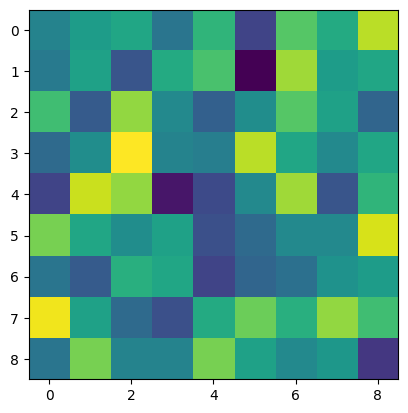

In [8]:
random_idx = np.random.randint(0, len(unit_rfs))
random_unit = unit_rfs[random_idx]
print(np.shape(random_unit))
print(random_unit)
plt.imshow(random_unit)

In [9]:
popt, r_squared, pcov, _ = fit_gaussian_to_rf(random_unit)

if popt is not None:
    x_idx = popt[1]
    y_idx = popt[2]
    x_pos = np.interp(x_idx, np.arange(len(xs)), xs)
    y_pos = np.interp(y_idx, np.arange(len(ys)), ys)
else:
    x_pos = None
    y_pos = None

In [10]:
print(popt)
print(r_squared)

[27.64193602  1.6836057   3.40823803  0.5         1.03658243  2.66692585
 77.02489944]
0.12008015887655166


In [11]:
print(x_pos)
print(y_pos)

-23.163942961616968
-5.917619722379421


In [12]:
print(pcov)

[[ 1.71134830e+02 -1.19113810e+00  1.04896589e+00 -1.62484176e+00
  -3.70057347e+00  1.50732064e+00  7.08645695e-01]
 [-1.19113810e+00  8.47683642e-02 -6.67880573e-02  1.60477791e-02
   3.73256481e-02 -4.15318942e-02 -2.82085951e-02]
 [ 1.04896589e+00 -6.67880573e-02  1.73199667e-01 -1.89291032e-02
  -2.39681416e-02  3.01828257e-02  2.59170838e-02]
 [-1.62484176e+00  1.60477791e-02 -1.89291032e-02  4.97599706e-02
   1.96550514e-02 -2.17715381e-02 -6.64818753e-02]
 [-3.70057347e+00  3.73256481e-02 -2.39681416e-02  1.96550514e-02
   2.34853615e-01 -4.20731206e-02 -1.46990754e-01]
 [ 1.50732064e+00 -4.15318942e-02  3.01828257e-02 -2.17715381e-02
  -4.20731206e-02  1.79208471e-01  3.33272787e-02]
 [ 7.08645695e-01 -2.82085951e-02  2.59170838e-02 -6.64818753e-02
  -1.46990754e-01  3.33272787e-02  1.66015733e+00]]


In [13]:
area_2sigma = np.pi * (2*popt[3]) * (2*popt[4])
print(area_2sigma)

6.513039500943603


### Do for 25 neurons with r^2 > 0.5

In [14]:
# Find all units with R² > 0.5
good_units = []

for idx, rf in enumerate(unit_rfs):
    result = fit_gaussian_to_rf(rf)
    if result[0] is not None:
        popt, r_squared, pcov, fitted_rf = result
        if r_squared > 0.5:
            area_2sigma = np.pi * (2*popt[3]) * (2*popt[4])
            area_1sigma = np.pi * popt[3] * popt[4]
            good_units.append({
                'unit_idx': unit_indices[idx],
                'rf': rf,
                'fitted_rf': fitted_rf,
                'popt': popt,
                'r_squared': r_squared,
                'area_2sigma': area_2sigma,
                'area_1sigma': area_1sigma
            })

print(f"Found {len(good_units)} units with R² > 0.5")



Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Bounded fit failed, trying unbounded fit: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Found 182 units with R² > 0.5


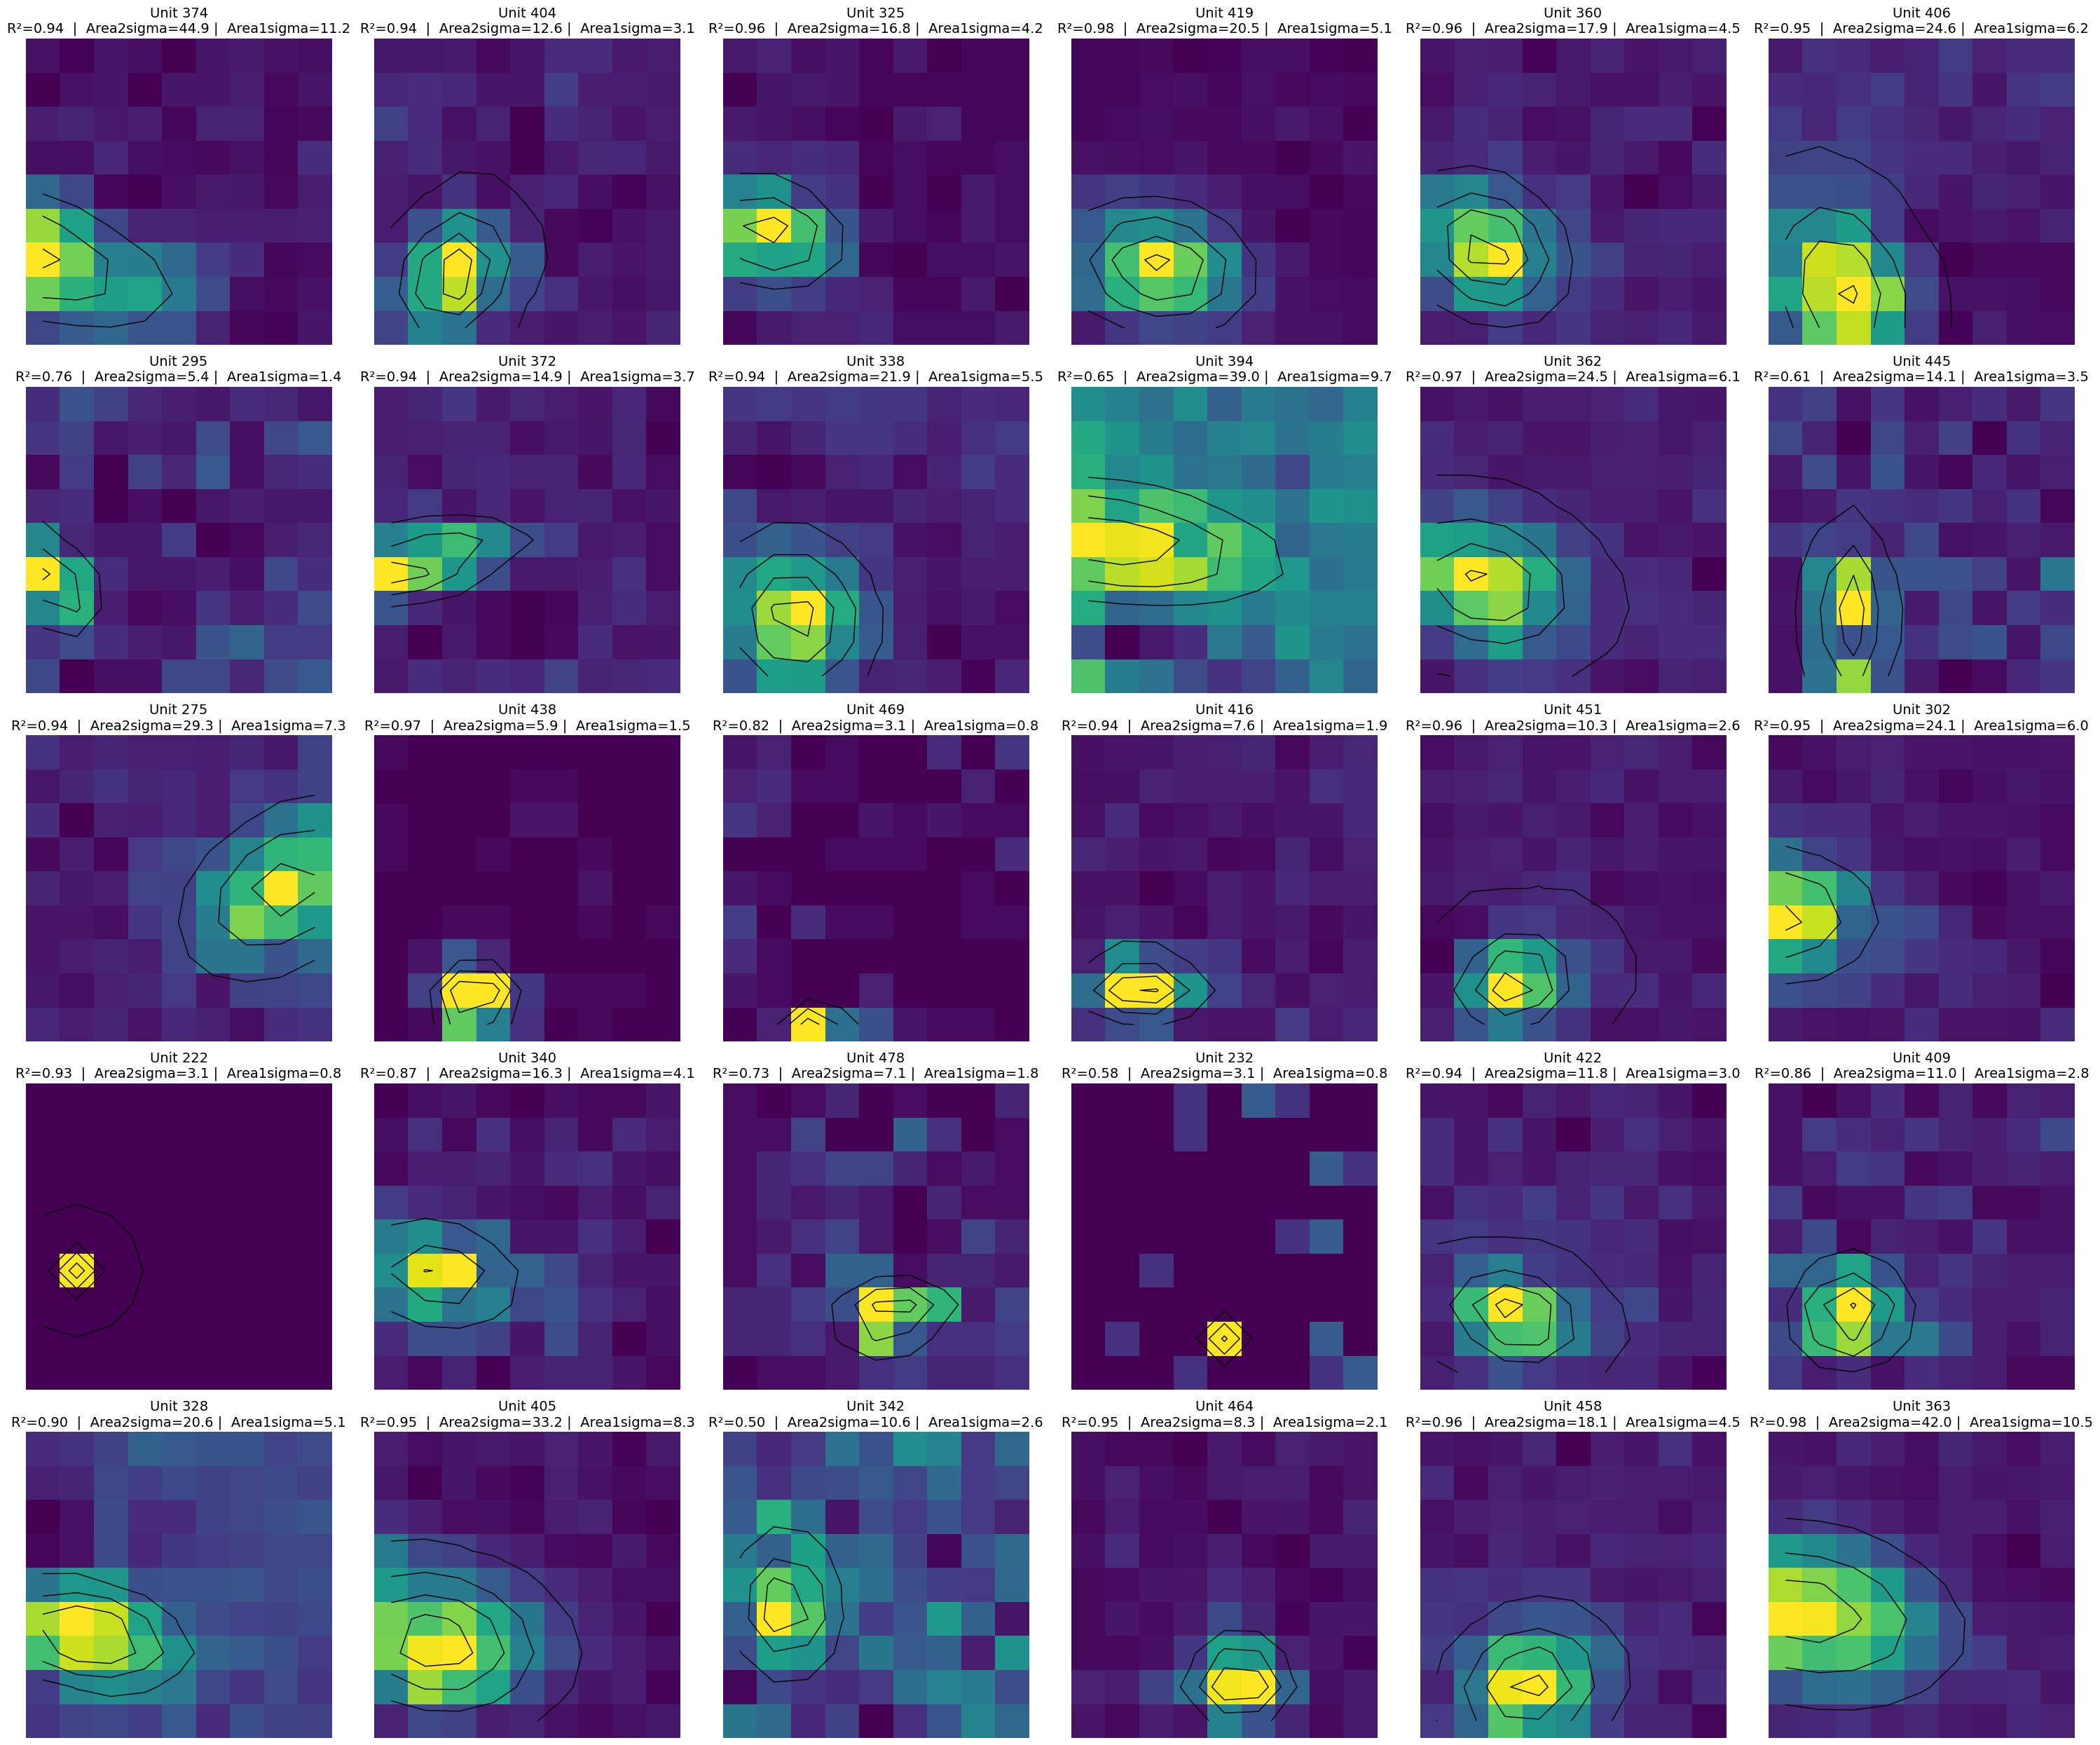

In [15]:

n_sample = min(30, len(good_units))
sampled_units = np.random.choice(good_units, size=n_sample, replace=False)

n_cols = int(np.ceil(np.sqrt(n_sample)))
n_rows = int(np.ceil(n_sample / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = np.array(axes).flatten()

for i, unit in enumerate(sampled_units):
    ax = axes[i]
    ax.imshow(unit['rf'], origin='lower', cmap='viridis')
    ax.contour(unit['fitted_rf'], levels=3, colors='black', linewidths=1)
    ax.set_title(f"Unit {unit['unit_idx']}\nR²={unit['r_squared']:.2f}  |  Area2sigma={unit['area_2sigma']:.1f} |  Area1sigma={unit['area_1sigma']:.1f}", fontsize=14)
    ax.axis('off')

# Hide any unused subplots
for j in range(n_sample, 25):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
